In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
df = pd.read_csv("cutoff.csv", on_bad_lines='skip')

df = df[['Rank 2025', 'Percentile 2025', 'College', 'Branch']]

df = df.dropna()

print(df.head())

   Rank 2025  Percentile 2025  \
0    37591.0          88.9551   
1    30071.0          91.1460   
2    58518.0          82.3322   
3    44130.0          86.9194   
4    41549.0          87.6872   

                                             College             Branch  
0  01002 - Government College of Engineering, Amr...  Civil Engineering  
1  01002 - Government College of Engineering, Amr...  Civil Engineering  
2  01002 - Government College of Engineering, Amr...  Civil Engineering  
3  01002 - Government College of Engineering, Amr...  Civil Engineering  
4  01002 - Government College of Engineering, Amr...  Civil Engineering  


In [ ]:
df['College'] = df['College'].str.lower().str.strip()

df['Branch'] = df['Branch'].str.lower().str.strip()

In [ ]:
print("\nFIRST 5 ROWS")
print(df.head())

print("\nLAST 5 ROWS")
print(df.tail())

print("\nDATASET INFO")
print(df.info())

print("\nSTATISTICAL SUMMARY")
print(df.describe())

print("\nMAX RANK")
print(df['Rank 2025'].max())

print("\nMIN RANK")
print(df['Rank 2025'].min())

print("\nMAX PERCENTILE")
print(df['Percentile 2025'].max())

print("\nMIN PERCENTILE")
print(df['Percentile 2025'].min())

print("\nTOTAL COLLEGES")
print(df['College'].nunique())

print("\nTOTAL BRANCHES")
print(df['Branch'].nunique())
print(df.info())


FIRST 5 ROWS
   Rank 2025  Percentile 2025  \
0    37591.0          88.9551   
1    30071.0          91.1460   
2    58518.0          82.3322   
3    44130.0          86.9194   
4    41549.0          87.6872   

                                             College             Branch  
0  01002 - government college of engineering, amr...  civil engineering  
1  01002 - government college of engineering, amr...  civil engineering  
2  01002 - government college of engineering, amr...  civil engineering  
3  01002 - government college of engineering, amr...  civil engineering  
4  01002 - government college of engineering, amr...  civil engineering  

LAST 5 ROWS
      Rank 2025  Percentile 2025  \
7555   131008.0          53.6771   
7556    75423.0          76.8956   
7557   147360.0          44.5303   
7558   156343.0          39.5742   
7559    78343.0          75.4881   

                                                College  \
7555  16121 - shri. anandrao abitkar college of engi..

In [ ]:
branch_encoded = pd.get_dummies(df['Branch'])

In [ ]:
X = pd.concat(
    [
        df[['Rank 2025', 'Percentile 2025']],
        branch_encoded
    ],
    axis=1
)

y = df['College']

In [ ]:
le = LabelEncoder()

y = le.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)


Accuracy: 0.1164021164021164


In [ ]:
rank = 5000

percentile = 95

branch = "artificial intelligence and machine learning"

In [ ]:
input_df = pd.DataFrame(columns=X.columns)

input_df.loc[0] = 0

input_df['Rank 2025'] = rank

input_df['Percentile 2025'] = percentile

if branch in branch_encoded.columns:

    input_df[branch] = 1

In [ ]:
prediction = model.predict(input_df)

college = le.inverse_transform(prediction)

print("\nPredicted College:")

print(college[0].title())


Predicted College:
03176 - Thakur College Of Engineering And Technology, Kandivali, Mumbai


In [ ]:
probs = model.predict_proba(input_df)[0]

top5_idx = np.argsort(probs)[-5:][::-1]

top_labels = []

top_probs = []

print("\nTop 5 College Options:\n")

for i in top5_idx:

    label = le.inverse_transform([i])[0]

    probability = probs[i] * 100

    top_labels.append(label.title())

    top_probs.append(probability)

    print(f"{label.title()} ({probability:.2f}%)")


Top 5 College Options:

03176 - Thakur College Of Engineering And Technology, Kandivali, Mumbai (21.67%)
03199 - Shri Vile Parle Kelvani Mandal'S Dwarkadas J. Sanghvi College Of Engineering, Vile Parle,Mumbai (14.33%)
06278 - All India Shri Shivaji Memorial Society'S College Of Engineering, Pune (12.00%)
03211 - S.I.E.S. Graduate School Of Technology, Nerul, Navi Mumbai (7.67%)
06273 - Bansilal Ramnath Agarawal Charitable Trust'S Vishwakarma Institute Of Technology, Bibwewadi, Pune (7.33%)


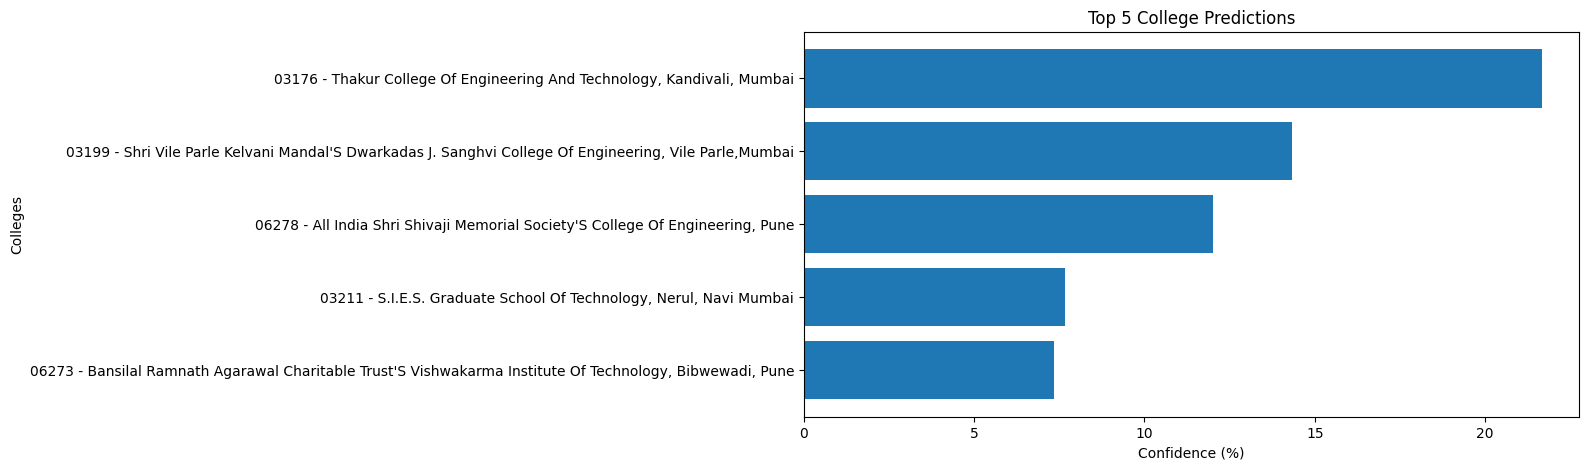

In [ ]:
plt.figure(figsize=(10,5))

plt.barh(top_labels, top_probs)

plt.xlabel("Confidence (%)")

plt.ylabel("Colleges")

plt.title("Top 5 College Predictions")

plt.gca().invert_yaxis()

plt.show()

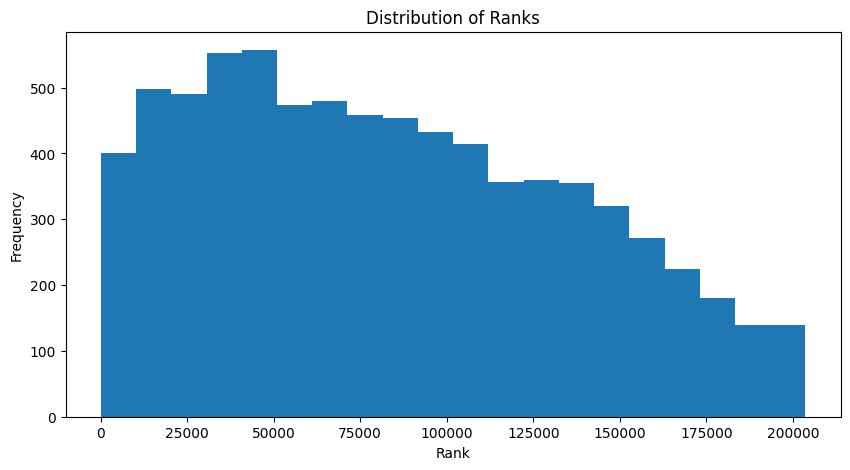

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(df['Rank 2025'], bins=20)

plt.xlabel("Rank")

plt.ylabel("Frequency")

plt.title("Distribution of Ranks")

plt.show()

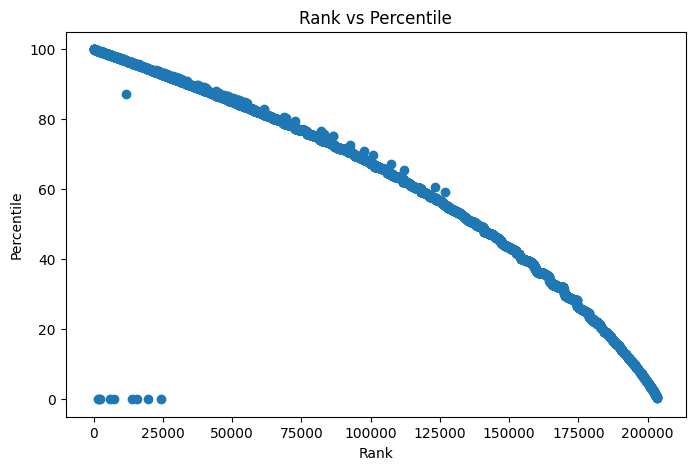

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Rank 2025'],
    df['Percentile 2025']
)

plt.xlabel("Rank")

plt.ylabel("Percentile")

plt.title("Rank vs Percentile")

plt.show()

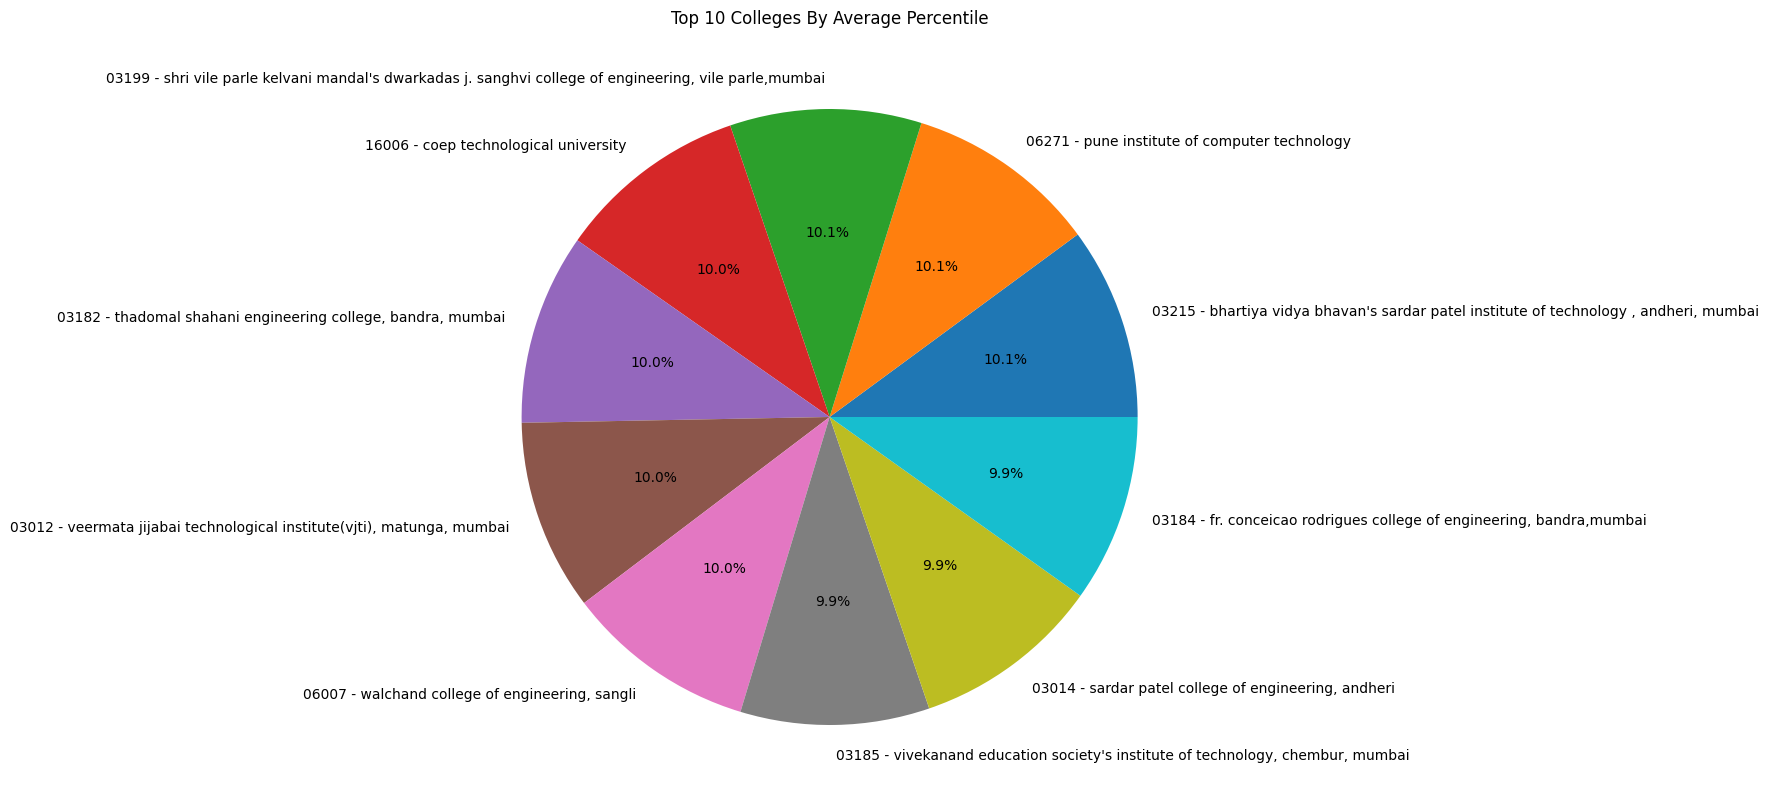

In [ ]:
top_colleges = df.groupby('College')['Percentile 2025'] \
                 .mean() \
                 .sort_values(ascending=False) \
                 .head(10)

plt.figure(figsize=(10,10))

plt.pie(
    top_colleges.values,
    labels=top_colleges.index,
    autopct='%1.1f%%'
)

plt.title("Top 10 Colleges By Average Percentile")

plt.show()

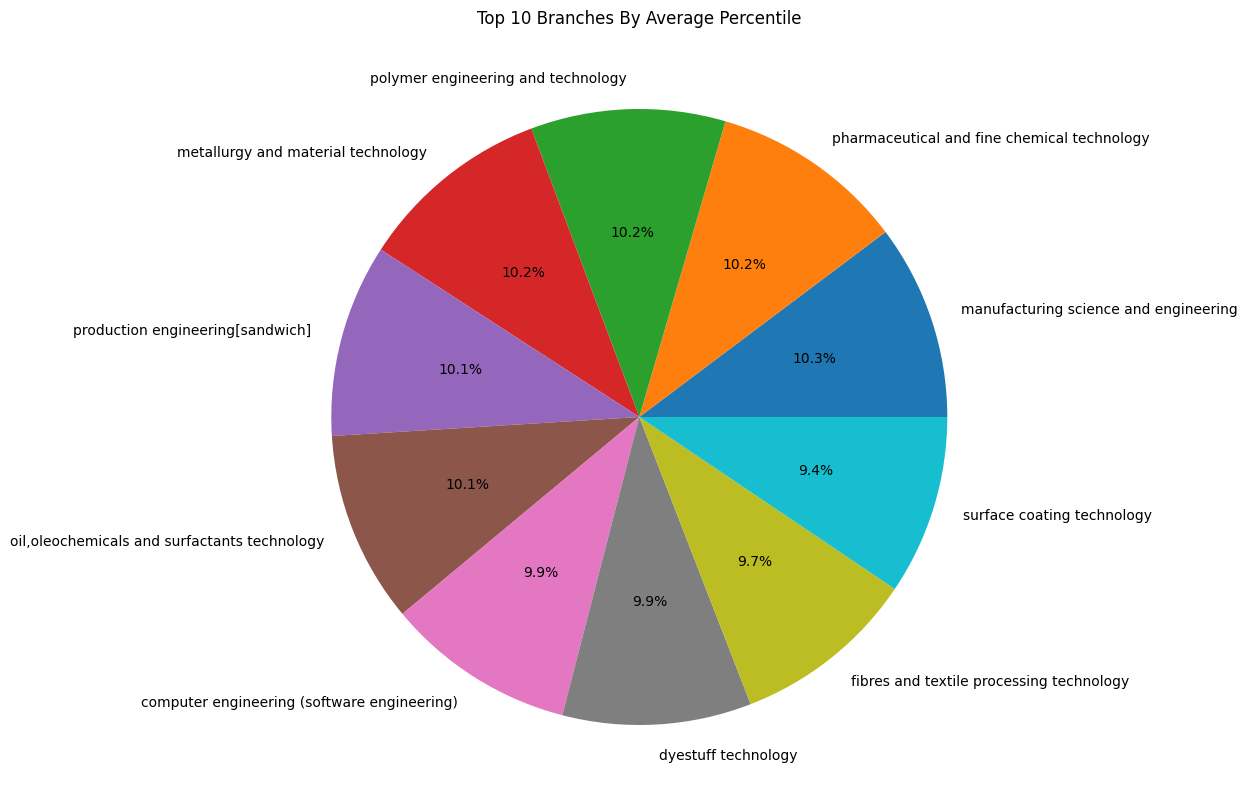

In [ ]:
top_branches = df.groupby('Branch')['Percentile 2025'] \
                 .mean() \
                 .sort_values(ascending=False) \
                 .head(10)

plt.figure(figsize=(10,10))

plt.pie(
    top_branches.values,
    labels=top_branches.index,
    autopct='%1.1f%%'
)

plt.title("Top 10 Branches By Average Percentile")

plt.show()

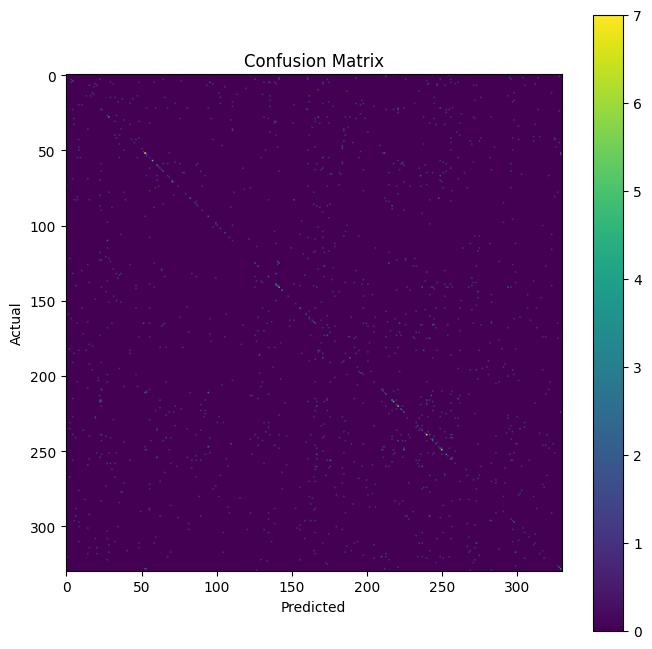

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,8))

plt.imshow(cm)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.colorbar()

plt.show()

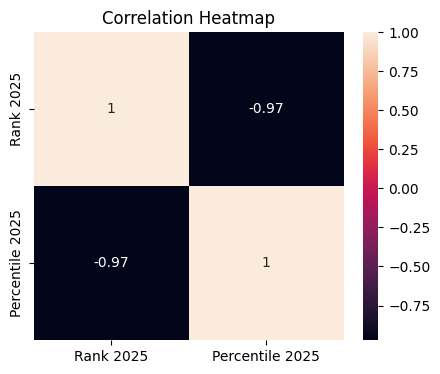

In [ ]:
import seaborn as sns

corr = df[['Rank 2025', 'Percentile 2025']].corr()

plt.figure(figsize=(5,4))

sns.heatmap(
    corr,
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()